# Penalized Cox Regression — LASSO & Elastic Net (R)

Applies L1 and elastic-net regularisation to the univariate-significant genes for
feature selection. Cross-validation selects the optimal penalty strength (λ),
then three external test sets are evaluated.

| Method | glmnet `alpha` | sksurv `l1_ratio` |
|--------|---------------|-------------------|
| LASSO  | 1.0 | 1.0 |
| Elastic Net | 0.9 | 0.9 |

**Depends on:** `univariate_cox_sig_train.csv` (from `univariate_cox_r.ipynb`)

**Libraries:** `survival`, `glmnet`, `ggplot2`, `reshape2`

In [16]:
# Uncomment to install
# install.packages(c('survival', 'glmnet', 'ggplot2', 'dplyr', 'reshape2'))

In [17]:
suppressPackageStartupMessages({
  library(survival)
  library(glmnet)
  library(ggplot2)
  library(dplyr)
  library(reshape2)
})

DATA_DIR <- '../../datasets/csv_files'
VIS_DIR  <- '../../visuals'
dir.create(VIS_DIR, showWarnings = FALSE, recursive = TRUE)
set.seed(0)
message('Packages loaded.')

Packages loaded.



## Preparing Data

In [18]:
sig_df <- read.csv(file.path(DATA_DIR, 'univariate_cox_sig_train.csv'),
                      stringsAsFactors = FALSE)
sig_genes <- sig_df$gene

expr_full <- read.csv(file.path(DATA_DIR, 'ml_datasets/train_data.csv'),
                      stringsAsFactors = FALSE)
test1 <- read.csv(file.path(DATA_DIR, 'ml_datasets/test_data_one.csv'),   stringsAsFactors = FALSE)
test2 <- read.csv(file.path(DATA_DIR, 'ml_datasets/test_data_two.csv'),   stringsAsFactors = FALSE)
test3 <- read.csv(file.path(DATA_DIR, 'ml_datasets/test_data_three.csv'), stringsAsFactors = FALSE)

cat(sprintf('%d univariate-significant genes loaded\n', length(sig_genes)))
expr_full[1:5, 1:6]

55 univariate-significant genes loaded


,sample_name,relapse_free_time,relapse_free_event,ACO1,ADAR,ADIPOQ
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,GSM1045208,3026,0,4.799942,11.39502,6.075966
2,GSM1045209,755,1,4.971609,10.86447,8.177897
3,GSM1045210,3014,0,4.555494,10.94212,6.828506
4,GSM1045211,406,1,4.668031,10.77627,5.196359
5,GSM1045212,2225,0,5.458046,11.74328,3.567575


In [19]:
filter_to_sig <- function(df, genes) {
  keep <- intersect(genes, names(df))
  df[, c('sample_name', 'relapse_free_event', 'relapse_free_time', keep), drop = FALSE]
}

train_filt <- filter_to_sig(expr_full, sig_genes)
train_filt <- train_filt[complete.cases(
  train_filt[c('relapse_free_time', 'relapse_free_event')]), ]
train_filt$relapse_free_event <- as.integer(train_filt$relapse_free_event)

gene_cols <- setdiff(names(train_filt),
                     c('sample_name', 'relapse_free_event', 'relapse_free_time'))
cat(sprintf('Training samples: %d | Significant genes: %d\n',
            nrow(train_filt), length(gene_cols)))

X_train <- as.matrix(train_filt[, gene_cols])
y_train <- Surv(train_filt$relapse_free_time, train_filt$relapse_free_event)

prep_test <- function(df, genes) {
  df    <- df[complete.cases(df[c('relapse_free_time', 'relapse_free_event')]), ]
  avail <- intersect(genes, names(df))
  list(X = as.matrix(df[, avail, drop = FALSE]),
       y = Surv(df$relapse_free_time, df$relapse_free_event))
}
t1 <- prep_test(test1, gene_cols)
t2 <- prep_test(test2, gene_cols)
t3 <- prep_test(test3, gene_cols)

cat(sprintf('Test 1: %d | Test 2: %d | Test 3: %d\n',
            nrow(t1$X), nrow(t2$X), nrow(t3$X)))

Training samples: 104 | Significant genes: 55


Test 1: 244 | Test 2: 88 | Test 3: 117


## Helper Functions

In [20]:
# Coefficient shrinkage path (analogous to Python plot_coefficients)
plot_coef_path <- function(fit, n_highlight = 10, title = 'Cox Coefficient Path') {
  mat <- as.matrix(fit$beta)
  df  <- melt(mat, varnames = c('gene', 'lambda_idx'), value.name = 'coef')
  df$log_lambda <- log(fit$lambda[df$lambda_idx])

  final_coefs <- abs(mat[, ncol(mat)])
  top_genes   <- names(sort(final_coefs, decreasing = TRUE))[seq_len(n_highlight)]
  df_top  <- df[df$gene %in% top_genes, ]
  df_rest <- df[!df$gene %in% top_genes, ]

  ggplot() +
    geom_line(data = df_rest, aes(x = log_lambda, y = coef, group = gene),
              colour = 'grey80', alpha = 0.5) +
    geom_line(data = df_top,  aes(x = log_lambda, y = coef,
                                  group = gene, colour = gene)) +
    geom_hline(yintercept = 0, linetype = 'dashed', colour = 'grey40') +
    labs(title = title, x = expression(log(lambda)),
         y = 'Coefficient', colour = 'Gene') +
    theme_bw(base_size = 10) +
    theme(plot.title = element_text(face = 'bold'), legend.position = 'right')
}

# CV concordance vs lambda
plot_cv_lambda <- function(cv_fit, title = 'CV Concordance vs Lambda') {
  df <- data.frame(log_lambda = log(cv_fit$lambda),
                   mean_cv = cv_fit$cvm, upper = cv_fit$cvup, lower = cv_fit$cvlo)
  ggplot(df, aes(x = log_lambda, y = mean_cv)) +
    geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.15, fill = '#4DBBD5') +
    geom_line(colour = '#4DBBD5') +
    geom_vline(xintercept = log(cv_fit$lambda.min),
               colour = '#E64B35', linetype = 'dashed') +
    geom_hline(yintercept = 0.5, colour = 'grey50', linetype = 'dashed') +
    labs(title = title, x = expression(log(lambda)), y = 'Concordance index (CV)') +
    theme_bw(base_size = 10) +
    theme(plot.title = element_text(face = 'bold'))
}

# Extract non-zero coefficient genes at best lambda
find_sig_genes <- function(cv_fit, gene_names) {
  best_coefs <- as.vector(coef(cv_fit, s = 'lambda.min'))
  names(best_coefs) <- gene_names
  nonzero <- best_coefs[best_coefs != 0]
  cat(sprintf('  Non-zero coefficients: %d\n', length(nonzero)))
  cat(sprintf('  Best CV C-index:       %.4f\n', max(cv_fit$cvm)))
  df_coef <- data.frame(gene = names(nonzero),
                         coefficient = round(as.vector(nonzero), 4),
                         stringsAsFactors = FALSE)
  df_coef <- df_coef[order(abs(df_coef$coefficient), decreasing = TRUE), ]
  print(df_coef)
  df_coef$gene
}

check_paper_genes <- function(gene_list) {
  paper   <- c('TSLP','BIRC5','S100B','MDK','S100P','RARRES3','BLNK','ACO1')
  found   <- intersect(paper, gene_list)
  missing <- setdiff(paper, gene_list)
  cat(sprintf('  Found (%d): %s\n',   length(found),   paste(found,   collapse = ', ')))
  cat(sprintf('  Missing (%d): %s\n', length(missing), paste(missing, collapse = ', ')))
}

## LASSO (alpha = 1 → pure L1)

Drives most coefficients to exactly zero — sparse feature selection.

Warning message:
"Starting in glmnet 5.1, the default Cox tie-handling method will change from 'breslow' to 'efron' (matching survival::coxph). To silence this message and lock in the v5.0 default, pass cox.ties = 'breslow' explicitly. To preview the v5.1 behavior, pass cox.ties = 'efron'."


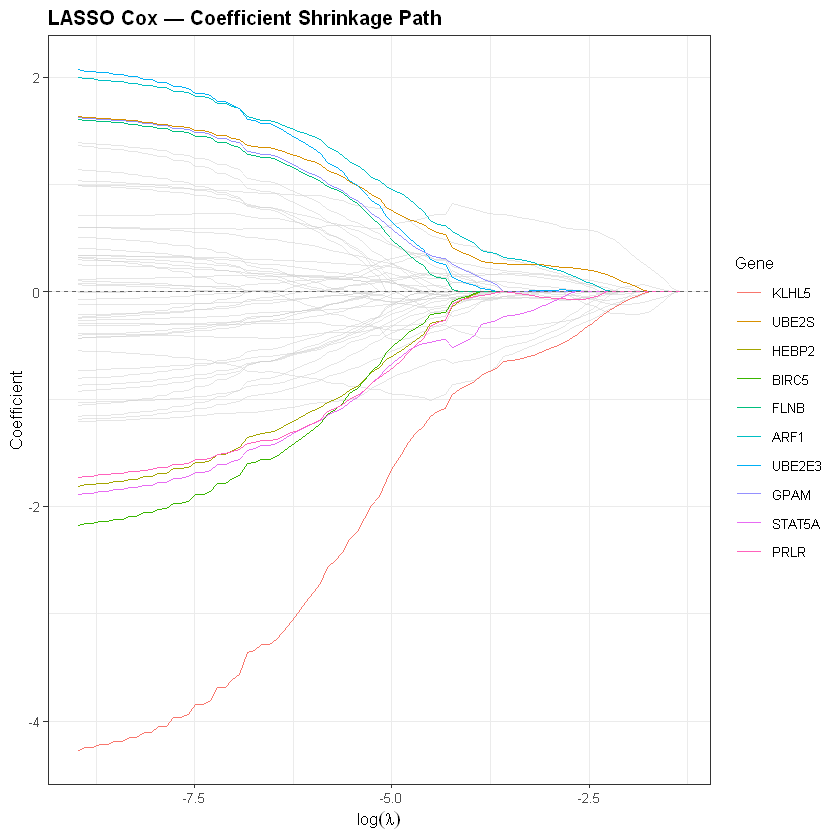

In [21]:
lasso_fit <- glmnet(X_train, y_train, family = 'cox', alpha = 1)

p_lasso_path <- plot_coef_path(lasso_fit,
                               title = 'LASSO Cox — Coefficient Shrinkage Path')
p_lasso_path
ggsave(file.path(VIS_DIR, 'lasso_coef_path.png'), p_lasso_path, dpi = 150, width = 9, height = 6)

Cross-validating LASSO (5-fold)...


Warning message:
"Starting in glmnet 5.1, the default Cox tie-handling method will change from 'breslow' to 'efron' (matching survival::coxph). To silence this message and lock in the v5.0 default, pass cox.ties = 'breslow' explicitly. To preview the v5.1 behavior, pass cox.ties = 'efron'."


Warning message:
"Starting in glmnet 5.1, the default Cox tie-handling method will change from 'breslow' to 'efron' (matching survival::coxph). To silence this message and lock in the v5.0 default, pass cox.ties = 'breslow' explicitly. To preview the v5.1 behavior, pass cox.ties = 'efron'."
Warning message:
"from glmnet C++ code (error code -70); Convergence for 70th lambda value not reached after maxit=100000 iterations; solutions for larger lambdas returned"
Warning message:
"Starting in glmnet 5.1, the default Cox tie-handling method will change from 'breslow' to 'efron' (matching survival::coxph). To silence this message and lock in the v5.0 default, pass cox.ties = 'breslow' explicitly. To preview the v5.1 behavior, pass cox.ties = 'efron'."
Warning message:
"from glmnet C++ code (error code -64); Convergence for 64th lambda value not reached after maxit=100000 iterations; solutions for larger lambdas returned"
Warning message:
"Starting in glmnet 5.1, the default Cox tie-handling


LASSO selected genes:
  Non-zero coefficients: 22
  Best CV C-index:       78.5767
      gene coefficient
5     SOX4      0.6300
3    KLHL5     -0.5068
8  DEFB132     -0.4187
13  FBXL16     -0.3578
17  MTHFD1     -0.3005
10    MICB     -0.2859
6    UBE2S      0.2406
11    ARF1      0.2046
19   CEBPD      0.1773
7    S100P      0.1537
21      TF      0.1441
15    SOD2      0.1192
20  STAT5A     -0.0816
4     BLNK     -0.0698
2  POLR3GL     -0.0685
22    PRLR     -0.0579
14     CFB     -0.0445
18     MDK      0.0361
9  COLEC12     -0.0206
12  UBE2E3      0.0158
16  CXCL14     -0.0046
1    FBXL5     -0.0008

Paper gene check:
  Found (3): MDK, S100P, BLNK
  Missing (5): TSLP, BIRC5, S100B, RARRES3, ACO1


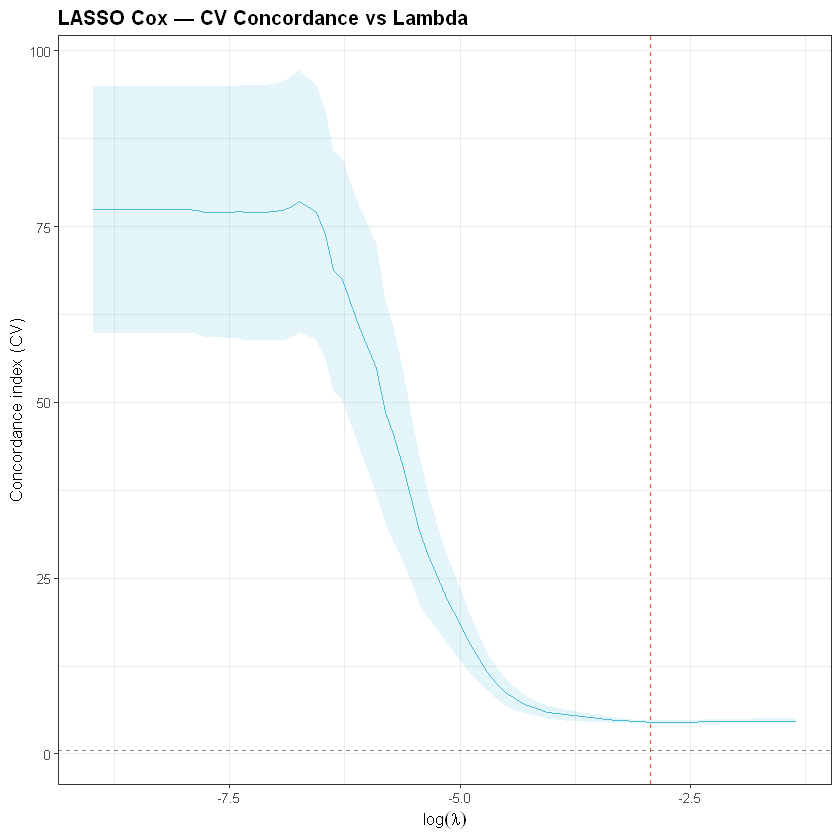

In [22]:
cat('Cross-validating LASSO (5-fold)...\n')
cv_lasso <- cv.glmnet(X_train, y_train, family = 'cox',
                      alpha = 1, nfolds = 5, standardize = TRUE)

p_lasso_cv <- plot_cv_lambda(cv_lasso, 'LASSO Cox — CV Concordance vs Lambda')
p_lasso_cv
ggsave(file.path(VIS_DIR, 'lasso_cv_lambda.png'), p_lasso_cv, dpi = 150, width = 9, height = 6)

cat('\nLASSO selected genes:\n')
lasso_genes <- find_sig_genes(cv_lasso, gene_cols)
cat('\nPaper gene check:\n')
check_paper_genes(lasso_genes)

## Elastic Net (alpha = 0.9 → 90% L1 / 10% L2)

Combines LASSO sparsity with Ridge stability — handles correlated predictors better.

Warning message:
"Starting in glmnet 5.1, the default Cox tie-handling method will change from 'breslow' to 'efron' (matching survival::coxph). To silence this message and lock in the v5.0 default, pass cox.ties = 'breslow' explicitly. To preview the v5.1 behavior, pass cox.ties = 'efron'."


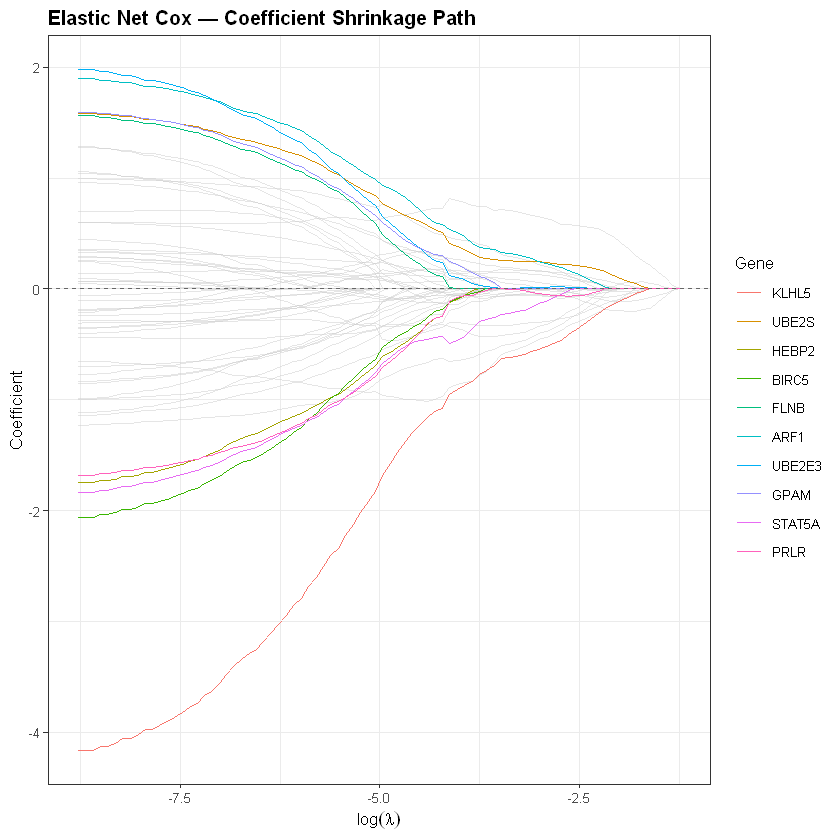

In [23]:
enet_fit <- glmnet(X_train, y_train, family = 'cox', alpha = 0.9)

p_enet_path <- plot_coef_path(enet_fit,
                              title = 'Elastic Net Cox — Coefficient Shrinkage Path')
p_enet_path
ggsave(file.path(VIS_DIR, 'elasticnet_coef_path.png'), p_enet_path, dpi = 150, width = 9, height = 6)

Cross-validating Elastic Net (5-fold)...


Warning message:
"Starting in glmnet 5.1, the default Cox tie-handling method will change from 'breslow' to 'efron' (matching survival::coxph). To silence this message and lock in the v5.0 default, pass cox.ties = 'breslow' explicitly. To preview the v5.1 behavior, pass cox.ties = 'efron'."


Warning message:
"Starting in glmnet 5.1, the default Cox tie-handling method will change from 'breslow' to 'efron' (matching survival::coxph). To silence this message and lock in the v5.0 default, pass cox.ties = 'breslow' explicitly. To preview the v5.1 behavior, pass cox.ties = 'efron'."
Warning message:
"Starting in glmnet 5.1, the default Cox tie-handling method will change from 'breslow' to 'efron' (matching survival::coxph). To silence this message and lock in the v5.0 default, pass cox.ties = 'breslow' explicitly. To preview the v5.1 behavior, pass cox.ties = 'efron'."
Warning message:
"Starting in glmnet 5.1, the default Cox tie-handling method will change from 'breslow' to 'efron' (matching survival::coxph). To silence this message and lock in the v5.0 default, pass cox.ties = 'breslow' explicitly. To preview the v5.1 behavior, pass cox.ties = 'efron'."
Warning message:
"from glmnet C++ code (error code -64); Convergence for 64th lambda value not reached after maxit=100000 it


Elastic Net selected genes:
  Non-zero coefficients: 24
  Best CV C-index:       47.7463
      gene coefficient
6     SOX4      0.5783
4    KLHL5     -0.4155
9  DEFB132     -0.3340
14  FBXL16     -0.2743
11    MICB     -0.2554
7    UBE2S      0.2177
19  MTHFD1     -0.2041
12    ARF1      0.1624
8    S100P      0.1355
21   CEBPD      0.1227
23      TF      0.1144
16    SOD2      0.0854
3  POLR3GL     -0.0794
5     BLNK     -0.0652
24    PRLR     -0.0645
1    FBXL5     -0.0578
10 COLEC12     -0.0332
15     CFB     -0.0327
20     MDK      0.0282
2      EVL     -0.0255
22  STAT5A     -0.0161
13  UBE2E3      0.0152
18  CXCL14     -0.0018
17  TRIM45     -0.0007

Paper gene check:
  Found (3): MDK, S100P, BLNK
  Missing (5): TSLP, BIRC5, S100B, RARRES3, ACO1

Best model (Elastic Net) selected 24 genes: SOX4, KLHL5, DEFB132, FBXL16, MICB, UBE2S, MTHFD1, ARF1, S100P, CEBPD, TF, SOD2, POLR3GL, BLNK, PRLR, FBXL5, COLEC12, CFB, MDK, EVL, STAT5A, UBE2E3, CXCL14, TRIM45


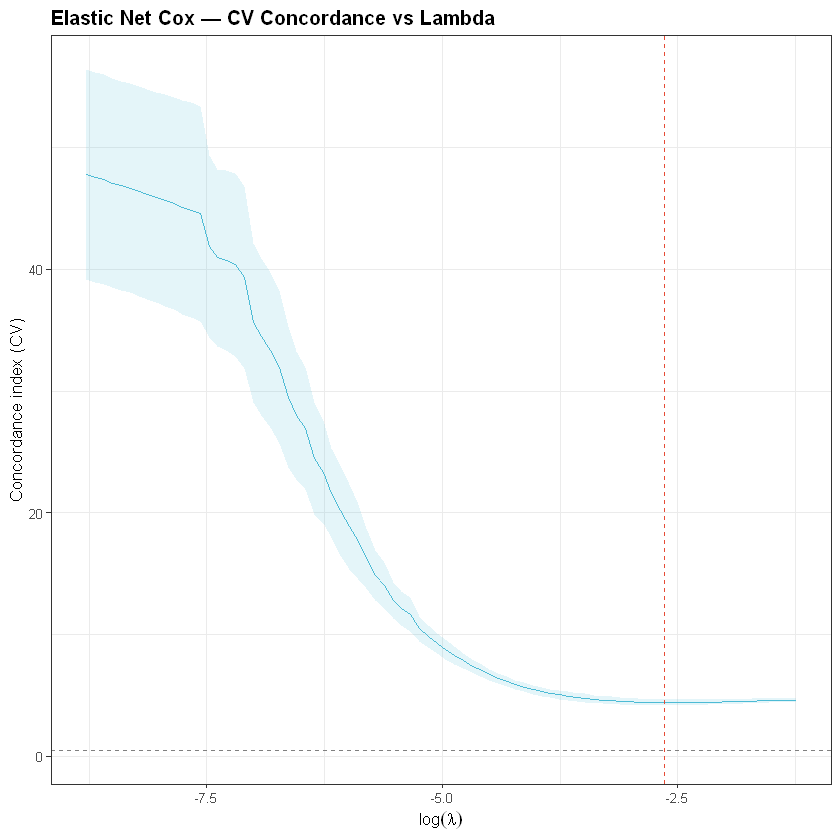

In [24]:
cat('Cross-validating Elastic Net (5-fold)...\n')
cv_enet <- cv.glmnet(X_train, y_train, family = 'cox',
                     alpha = 0.9, nfolds = 5, standardize = TRUE)

p_enet_cv <- plot_cv_lambda(cv_enet, 'Elastic Net Cox — CV Concordance vs Lambda')
p_enet_cv
ggsave(file.path(VIS_DIR, 'elasticnet_cv_lambda.png'), p_enet_cv, dpi = 150, width = 9, height = 6)

cat('\nElastic Net selected genes:\n')
enet_genes <- find_sig_genes(cv_enet, gene_cols)
cat('\nPaper gene check:\n')
check_paper_genes(enet_genes)

best_model <- enet_genes
cat(sprintf('\nBest model (Elastic Net) selected %d genes: %s\n',
            length(best_model), paste(best_model, collapse = ', ')))

## Test Data C-Index

In [25]:
compute_cindex <- function(cv_fit, X_new, y_new) {
  lp <- as.vector(predict(cv_fit, newx = X_new, s = 'lambda.min', type = 'link'))
  concordance(y_new ~ lp)$concordance
}

ci_test1 <- compute_cindex(cv_enet, t1$X, t1$y)
ci_test2 <- compute_cindex(cv_enet, t2$X, t2$y)
ci_test3 <- compute_cindex(cv_enet, t3$X, t3$y)

cat(sprintf('Test Set 1 C-Index: %.4f\n', ci_test1))
cat(sprintf('Test Set 2 C-Index: %.4f\n', ci_test2))
cat(sprintf('Test Set 3 C-Index: %.4f\n', ci_test3))

Test Set 1 C-Index: 0.3883
Test Set 2 C-Index: 0.4594
Test Set 3 C-Index: 0.3395


## Save Results

In [26]:
sig_expr <- filter_to_sig(expr_full, best_model)
sig_expr <- sig_expr[complete.cases(
  sig_expr[c('relapse_free_time', 'relapse_free_event')]), ]

write.csv(sig_expr, file.path(DATA_DIR, 'penalized_cox_sig_genes_train.csv'),
          row.names = FALSE)

cat('Saved: penalized_cox_sig_genes_train.csv\n')
cat('Saved plots: lasso_coef_path.png, lasso_cv_lambda.png,\n')
cat('             elasticnet_coef_path.png, elasticnet_cv_lambda.png\n')
cat('\n--- Next steps ---\n')
cat('  Feed penalized_cox_sig_genes_train.csv into multivariate_cox_r.ipynb\n')

Saved: penalized_cox_sig_genes_train.csv
Saved plots: lasso_coef_path.png, lasso_cv_lambda.png,
             elasticnet_coef_path.png, elasticnet_cv_lambda.png

--- Next steps ---
  Feed penalized_cox_sig_genes_train.csv into multivariate_cox_r.ipynb
